In [40]:
from datasets import load_dataset, concatenate_datasets
import ast
import re
from tqdm import tqdm
import torch
import numpy as np
import json
import csv
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from scipy.spatial.distance import cdist
from threading import Thread
from IntrinsicDim import PHD

Функции для загрузки и обработку текстов:

In [6]:
def normalize_expression(expression):
    """
    Проверяет, является ли выражение байтовым литералом, последовательностью байт
    и возвращает его в формате строки.
    """
    # Случай, когда тип выражения - bytes
    if isinstance(expression, bytes):
        return expression.decode('utf-8')
    # Случай, когда тип выражения - строка
    if isinstance(expression, str):
        try:
            byte_val = ast.literal_eval(expression)
            if isinstance(byte_val, bytes):
                return byte_val.decode('utf-8')
        except:
            pass

    return str(expression)

In [7]:
def load_wiki40b(lang):
    """Загружает датасет на требуемом языке"""
    return load_dataset('wiki40b', lang)

In [8]:
def find_article_by_wikidata_id(dataset_dict, wikidata_id):
    """В датасете находит статью по wikidata_id."""

    for split in ['train', 'validation', 'test']:
        for example in dataset_dict[split]:
            if normalize_expression(example['wikidata_id']) == normalize_expression(wikidata_id):
                return normalize_expression(example['text'])
    return None

In [21]:
def create_id_dict(dataset_dict):
    """
    Создаёт индекс wikidata_id - позиция в датасете для быстрого доступа к статьям по wikidata_id
    """
    id_dict = {}
    for split in ['train', 'validation', 'test']:
        for i, article in enumerate(tqdm(dataset_dict[split], desc=f"Построение словаря {split}")):
            normalized_id = normalize_expression(article['wikidata_id'])
            if normalized_id not in id_dict:
                id_dict[normalized_id] = {
                    'position': i,
                    'split'   : split
                }
    return id_dict

In [10]:
def find_common_articles(index_lang1, index_lang2, n_articles=None):
    """
    Находит n_articles статей, которые есть в обоих языках.
    """
    common_ids = set(index_lang1.keys()) & set(index_lang2.keys())

    selected_ids = list(common_ids)
    if n_articles is not None:
        selected_ids = selected_ids[:n_articles]

    return selected_ids

In [11]:
def clean_article(text):
    """
    Убирает служебную разметку.
    """
    normalized_text = normalize_expression(text)
    normalized_text = re.sub(r'_(START_ARTICLE|START_SECTION|START_PARAGRAPH|NEWLINE)_', ' ', normalized_text)
    normalized_text = re.sub(r'\s+', ' ', normalized_text)

    return normalized_text.strip()

In [12]:
def find_articles_by_id(id_index, dataset_dict, common_ids):
    """
    Извлекает тексты статей по списку id.
    """
    articles = []

    for article_id in tqdm(common_ids, desc="Извлечение статей"):
        if article_id not in id_index:
            print(f"Предупреждение: ID {article_id} не найден в индексе")
            continue

        article_pos = id_index[article_id]
        split = article_pos['split']
        position = article_pos['position']

        try:
            article_text = dataset_dict[split][position]['text']
            clean_text = clean_article(article_text)

            articles.append({
                'wikidata_id': article_id,
                'text': clean_text,
            })
        except Exception as e:
            print(f"Ошибка при извлечении статьи {article_id}: {e}")

    return articles

Функции для подсчёта PHD:

In [13]:
def preprocess_text(text):
    return text.replace('\n', ' ').replace('  ', ' ')

In [44]:
def get_phd_single(model, tokenizer, text, solver):
    """
    Получение PHD для одного текста.
    """
    inputs = tokenizer(preprocess_text(text), truncation=True, max_length=512, return_tensors="pt")
    inputs = {key: tensor.to(model.device) for key, tensor in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = outputs.last_hidden_state[0].cpu().numpy()

    if embeddings.shape[0] > 2:
        embeddings = embeddings[1:-1]

    mx_points = embeddings.shape[0]
    mn_points = MIN_SUBSAMPLE

    if mx_points <= mn_points:
        mn_points = max(3, mx_points // 2)

    step = max(1, (mx_points - mn_points) // INTERMEDIATE_POINTS)

    max_points = mx_points - step
    if max_points <= mn_points:
        max_points = mn_points + 1

    return solver.fit_transform(embeddings, min_points=mn_points, max_points=mx_points - step, point_jump=step)

In [29]:
def get_phd_for_all_articles(model, tokenizer, articles, alpha=1.0, n_points=9):
    """
    Считает PHD для всех статей.
    """
    phd_solver = PHD(alpha=alpha, metric='euclidean', n_points=n_points)
    dims = []

    for article in tqdm(articles, desc="Вычисление PHD"):

        phd_value = get_phd_single(model, tokenizer, article['text'], phd_solver)
        dims.append({
            'wikidata_id': article['wikidata_id'],
            'phd_value': phd_value,
        })

    return dims

Загружаем датасеты:

In [16]:
data_ru = load_wiki40b("ru")
data_en = load_wiki40b("en")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

ru/train-00000-of-00029.parquet:   0%|          | 0.00/152M [00:00<?, ?B/s]

ru/train-00001-of-00029.parquet:   0%|          | 0.00/152M [00:00<?, ?B/s]

...

en/test-00001-of-00002.parquet:   0%|          | 0.00/155M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2926536 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/163597 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/162274 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Для каждого датасета создаём словарь с wikidata_id статьи в качестве индекса:

In [22]:
dict_ru = create_id_dict(data_ru)
dict_en = create_id_dict(data_en)

Построение словаря test: 100%|██████████| 162274/162274 [00:11<00:00, 14004.49it/s]


Находим статьи, которые есть в обоих датасетах:

In [41]:
n_articles = 500
common_ids = find_common_articles(dict_ru, dict_en, n_articles)

Получаем тексты общих статей:

In [42]:
articles_ru = find_articles_by_id(dict_ru, data_ru, common_ids)
articles_en = find_articles_by_id(dict_en, data_en, common_ids)

Извлечение статей: 100%|██████████| 500/500 [00:03<00:00, 160.11it/s]


Загружаем модель:

In [26]:
MIN_SUBSAMPLE = 40
INTERMEDIATE_POINTS = 7

model_path = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_path,
    trust_remote_code=True,
    device_map="auto",
    dtype=torch.float16
)

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Считаем внутренние размерности:

In [ ]:
phd_results_ru = get_phd_for_all_articles(model, tokenizer, articles_ru)

In [ ]:
phd_results_en = get_phd_for_all_articles(model, tokenizer, articles_en)

Собираем данные в удобный формат:

In [46]:
all_results = []
for i, (ru, en) in enumerate(zip(phd_results_ru, phd_results_en)):
    all_results.append({
        'index': i + 1,
        'wikidata_id': ru['wikidata_id'],
        'phd_ru': ru['phd_value'],
        'phd_en': en['phd_value']
    })

Строим график внутренних размерностей:

In [84]:
def plot_phd(results, save_path=None):
    """
    График для сравнения phd на двух языках.
    """
    indices = [res['index'] for res in results]

    plt.figure(figsize=(15, 8))
    plt.plot(indices, [res['phd_ru'] for res in results], color="blue", label="Русский")
    plt.plot(indices, [res['phd_en'] for res in results], color="red", label="Английский")

    plt.xlabel("Номер статьи")
    plt.ylabel("Размерность PHD")
    plt.title("Сравнение внутренней размерности для текстов на английском и русском")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 20)

    if save_path:
        plt.savefig(save_path)
    plt.show()

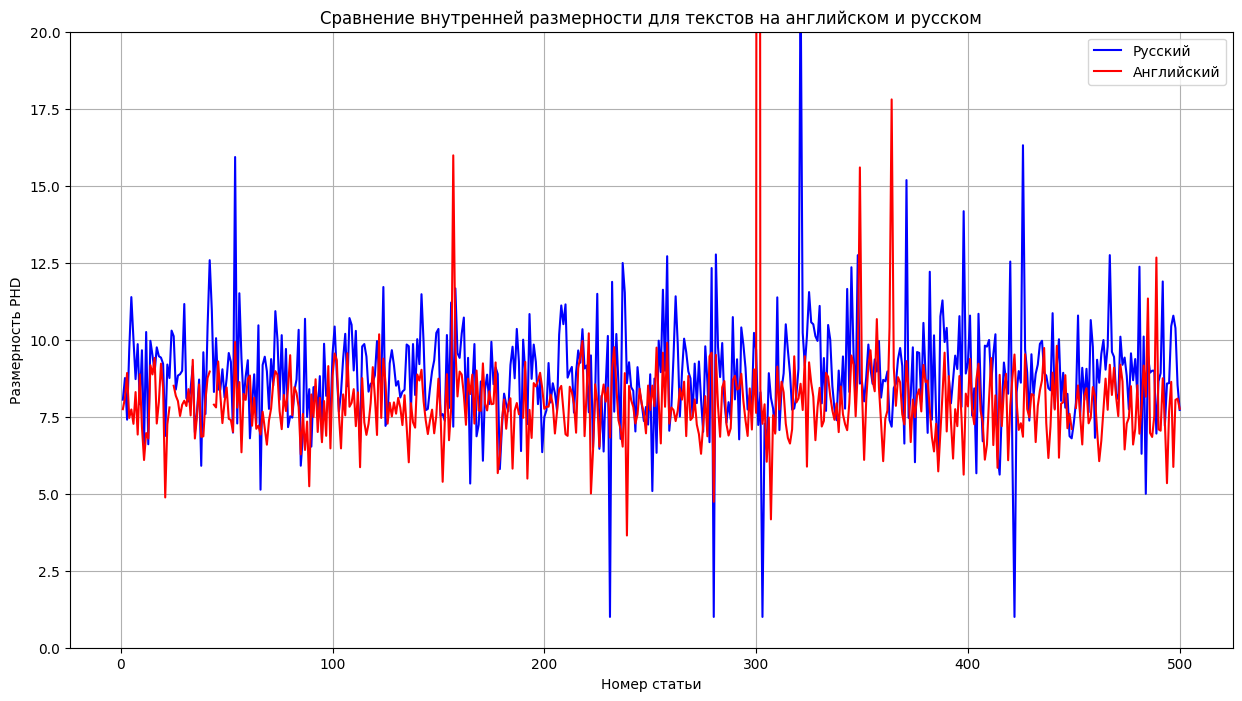

In [85]:
plot_phd(all_results, save_path="phd_comparison.png")

График для разности phd на двух языках:

In [81]:
def plot_phd_diff(results, save_path=None):
    """
    График для сравнения phd на двух языках.
    """
    indices = [res['index'] for res in results]
    diff = [(res['phd_ru'] - res['phd_en']) for res in results]

    plt.figure(figsize=(15, 8))
    plt.plot(indices, diff, color="blue", label="Разность PHD")

    plt.xlabel("Номер статьи")
    plt.ylabel("Разность PHD")
    plt.title("Разность PHD для текстов на русском и английском")
    plt.legend()
    plt.grid(True)
    plt.ylim(-10, 10)

    if save_path:
        plt.savefig(save_path)
    plt.show()

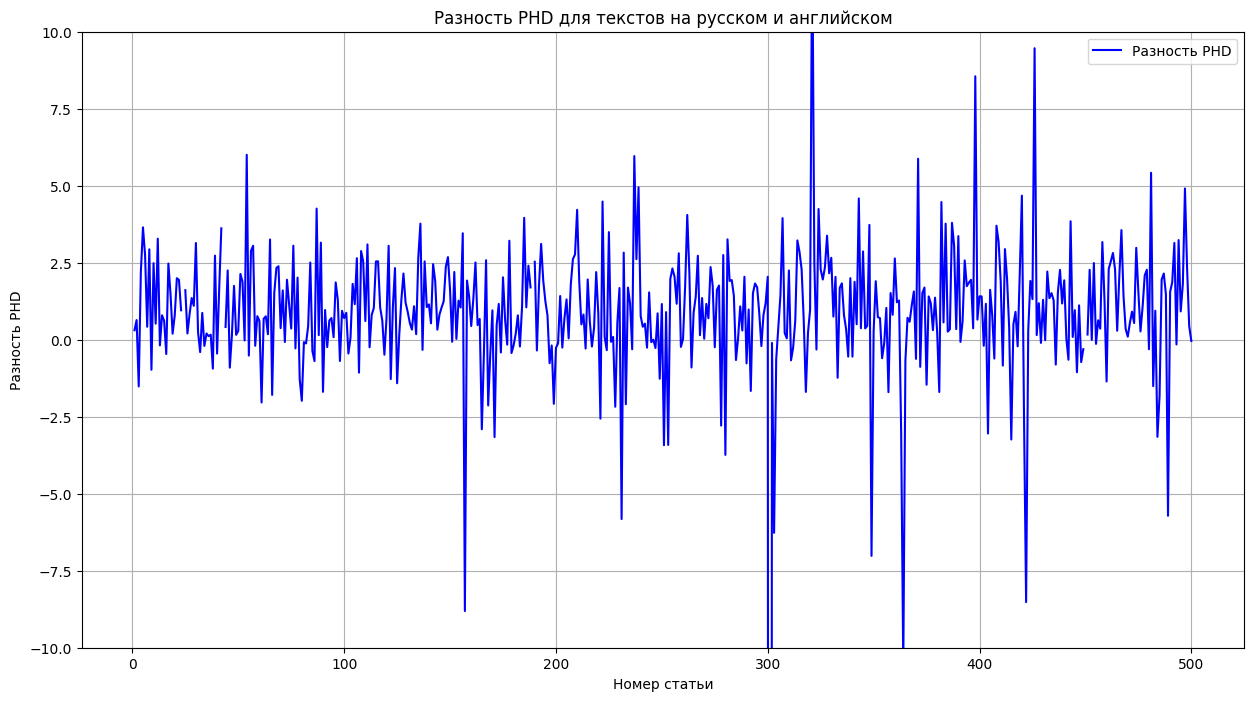

In [82]:
plot_phd_diff(all_results, save_path="phd_diff.png")

Сохраняем данные на будущее:

In [88]:
def save_phd_results(all_results, name="phd_results"):
    """Сохраняет результаты в JSON"""

    with open(f'{name}.json', 'w', encoding='utf-8') as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)

    return all_results

def load_phd_results(name="phd_results"):
    """Загружает результаты из JSON"""

    with open(f'{name}.json', 'r', encoding='utf-8') as f:
        return json.load(f)

In [89]:
saved_data = save_phd_results(all_results, name="ru_en_phd_results")